83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 1s 4us/step


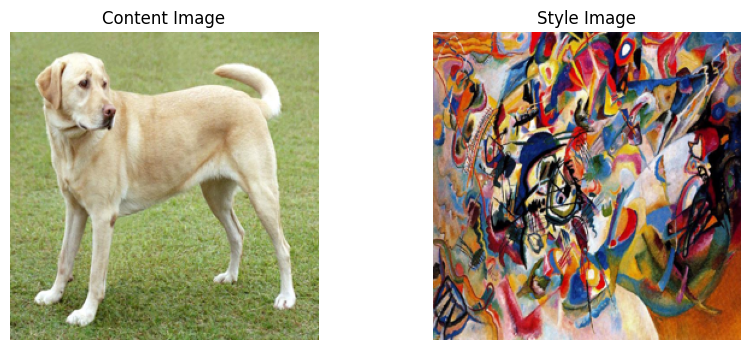

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

from PIL import Image

# Download images using tensorflow (bypasses URL blocking)

content_path = tf.keras.utils.get_file(
    "content.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
)

style_path = tf.keras.utils.get_file(
    "style.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg"
)

# Load images

def load_image(path, max_dim=256):

    img = Image.open(path).convert("RGB")

    img = img.resize((max_dim, max_dim))

    img = np.array(img, dtype=np.float32)

    return np.expand_dims(img, axis=0)

def deprocess(img):

    img = np.squeeze(img.copy())

    return np.clip(img, 0, 255).astype("uint8")

content_image = load_image(content_path)

style_image = load_image(style_path)

plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.imshow(deprocess(content_image))
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(deprocess(style_image))
plt.title("Style Image")
plt.axis("off")

plt.show()